In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import acf

In [10]:

for root, dirs, files in os.walk(".."):
    for f in files:
        if "safety" in f.lower() or "ward" in f.lower():
            print(os.path.join(root, f))

../data/wards/Wards.geojson
../notebooks/17_assign_ward_safety_to_sensors.ipynb
../notebooks/18_glm_with_safety.ipynb
../notebooks/16_prepare_safety_inputs.ipynb
../reports/glm_ped_safety_summary.txt
../reports/sensor_ward_safety_after_dark_2024.csv
../reports/glm_ped_safety_coefficients.csv
../reports/glm_ped_safety_diagnostics.csv
../reports/sensor_safety_inputs_template.csv


In [11]:
BIG_PATH = "../data/mdm2_data_files/big_table_with_weather_and_rain_with_geo_clusters_v2.csv"
SAFETY_PATH = "../reports/sensor_ward_safety_after_dark_2024.csv"
OUT_PATH = "../data/mdm2_data_files/big_table_weather_rain_clusters_safety.csv"

big = pd.read_csv(BIG_PATH)
safe = pd.read_csv(SAFETY_PATH)

big["sensor_id"] = big["sensor_id"].astype(int)
safe["sensor_id"] = safe["sensor_id"].astype(int)

print("BIG:", big.shape, "unique sensors:", big["sensor_id"].nunique())
print("SAFE:", safe.shape, "unique sensors:", safe["sensor_id"].nunique())
print("SAFE cols:", safe.columns.tolist())

# detect safety column (usually safety_scaled is already present in this file)
if "safety_scaled" in safe.columns:
    safe_small = safe[["sensor_id", "safety_scaled"]].copy()
else:
    # fallback: look for a numeric column with safety in the name
    candidates = [c for c in safe.columns if "safety" in c.lower() or "safe" in c.lower()]
    if not candidates:
        raise ValueError("No safety column found. Tell me the correct column name from SAFE cols above.")
    safety_col = candidates[0]
    safe_small = safe[["sensor_id", safety_col]].copy()
    # scale it 0..1
    v = safe_small[safety_col].astype(float)
    safe_small["safety_scaled"] = (v - v.min()) / (v.max() - v.min())
    safe_small = safe_small[["sensor_id", "safety_scaled"]]

# if duplicates exist, average per sensor
safe_small = safe_small.groupby("sensor_id", as_index=False)["safety_scaled"].mean()

merged = big.merge(safe_small, on="sensor_id", how="left")

print("MERGED:", merged.shape)
print("Missing safety_scaled rate:", merged["safety_scaled"].isna().mean())

merged.to_csv(OUT_PATH, index=False)
print("Saved:", OUT_PATH)

BIG: (379477, 19) unique sensors: 46
SAFE: (46, 3) unique sensors: 46
SAFE cols: ['sensor_id', 'ward_name', 'safety_after_dark_pct']
MERGED: (379477, 20)
Missing safety_scaled rate: 0.0
Saved: ../data/mdm2_data_files/big_table_weather_rain_clusters_safety.csv


In [12]:
df = pd.read_csv("../data/mdm2_data_files/big_table_weather_rain_clusters_safety.csv")
print("Has safety_scaled:", "safety_scaled" in df.columns)
print("Missing safety:", df["safety_scaled"].isna().mean())
print("Sensors:", df["sensor_id"].nunique())

Has safety_scaled: True
Missing safety: 0.0
Sensors: 46


In [14]:
DATA_PATH = "../data/mdm2_data_files/big_table_weather_rain_clusters_safety.csv"

TAG = "cyc_safety_clustered"

OUT_FIG_DIR = "../figures"
OUT_REP_DIR = "../reports"
os.makedirs(OUT_FIG_DIR, exist_ok=True)
os.makedirs(OUT_REP_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

print("Loaded:", df.shape)
print("Columns:", df.columns.tolist())

Loaded: (379477, 20)
Columns: ['ped', 'car', 'cyc', 'sensor_id', 'datetime', 'hour', 'date_only', 'dow', 'longitude', 'latitude', 'weekday', 'month', 'solar_altitude_deg', 'light_class', 'Dark', 'temp_c', 'wind_ms', 'rain_mm', 'cluster_geo', 'safety_scaled']


In [16]:
HOUR_MIN, HOUR_MAX = 6, 21   # inclusive lower, inclusive upper
df = df[(df["hour"] >= HOUR_MIN) & (df["hour"] <= HOUR_MAX)].copy()

print("After hour filter:", df.shape)
print("Hour min/max:", df["hour"].min(), df["hour"].max())

After hour filter: (249602, 20)
Hour min/max: 6 21


In [24]:
# make sure all columns used in formula are non-missing
needed = [
    "cyc","sensor_id","cluster_geo",
    "hour","dow","month",
    "temp_c","wind_ms","rain_mm",
    "Dark","safety_scaled"
]

df = df.dropna(subset=needed).copy()

# OPTIONAL: hour window for cyclists
df = df[(df["hour"] >= 6) & (df["hour"] <= 21)].copy()

# IMPORTANT: reset index so rows align perfectly for clustering
df = df.reset_index(drop=True)

formula = """
cyc ~
C(cluster_geo) + C(hour) + C(dow) + C(month)
+ temp_c + wind_ms + rain_mm
+ Dark*C(cluster_geo)
+ safety_scaled
"""

print("Fitting Negative Binomial GLM (cluster robust by sensor_id)...")
model = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.NegativeBinomial()
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["sensor_id"].values}
)

print(model.summary())

dispersion = model.pearson_chi2 / model.df_resid
print("\nDispersion:", dispersion)

Fitting Negative Binomial GLM (cluster robust by sensor_id)...
                 Generalized Linear Model Regression Results                  
Dep. Variable:                    cyc   No. Observations:               249602
Model:                            GLM   Df Residuals:                   249560
Model Family:        NegativeBinomial   Df Model:                           41
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.0175e+06
Date:                Thu, 05 Mar 2026   Deviance:                   4.2247e+05
Time:                        13:32:23   Pearson chi2:                 3.62e+05
No. Iterations:                    19   Pseudo R-squ. (CS):             0.2928
Covariance Type:              cluster                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [38]:
[p for p in model.params.index if "safety_scaled" in p]

['safety_scaled']

In [25]:
df.groupby("cluster_geo")["cyc"].describe()

,count,mean,std,min,25%,50%,75%,max
cluster_geo,,,,,,,,
0,130224.0,17.401370,19.345526,0.0,5.0,12.0,23.0,750.0
1,32563.0,23.443233,41.668099,0.0,0.0,6.0,30.0,480.0
2,86815.0,37.803433,55.298217,0.0,3.0,19.0,49.0,533.0


In [26]:
df.groupby("cluster_geo")["cyc"].sum()

cluster_geo
0    2266076
1     763382
2    3281905
Name: cyc, dtype: int64

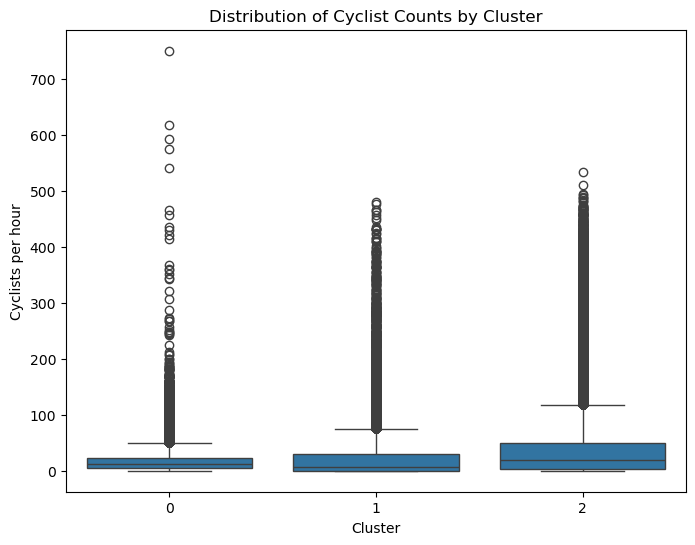

In [27]:
import seaborn as sns
plt.figure(figsize=(8,6))

sns.boxplot(x="cluster_geo", y="cyc", data=df)

plt.xlabel("Cluster")
plt.ylabel("Cyclists per hour")
plt.title("Distribution of Cyclist Counts by Cluster")

plt.show()

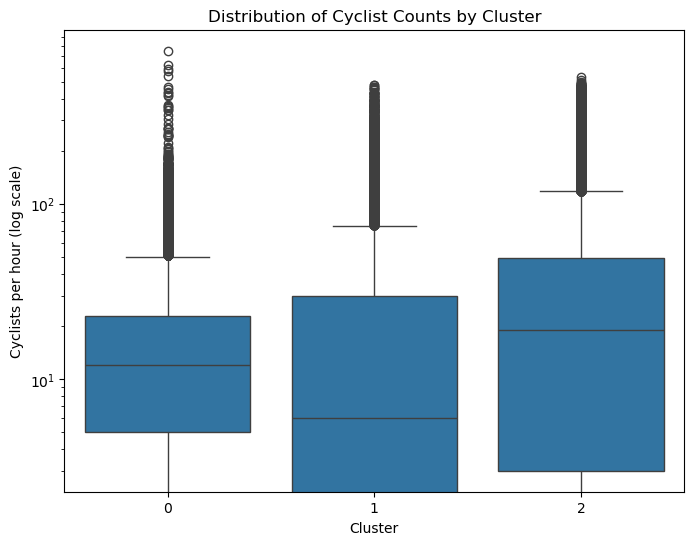

In [28]:
plt.figure(figsize=(8,6))

sns.boxplot(x="cluster_geo", y="cyc", data=df)

plt.yscale("log")

plt.xlabel("Cluster")
plt.ylabel("Cyclists per hour (log scale)")
plt.title("Distribution of Cyclist Counts by Cluster")

plt.show()

In [29]:
params = model.params

for c in [0,1,2]:
    beta = params["Dark"]
    
    if c > 0:
        beta += params[f"Dark:C(cluster_geo)[T.{c}]"]
    
    effect = (np.exp(beta)-1)*100
    print(f"Cluster {c}: {effect:.2f}% change in cyclists")

Cluster 0: -3.11% change in cyclists
Cluster 1: 21.37% change in cyclists
Cluster 2: -24.08% change in cyclists


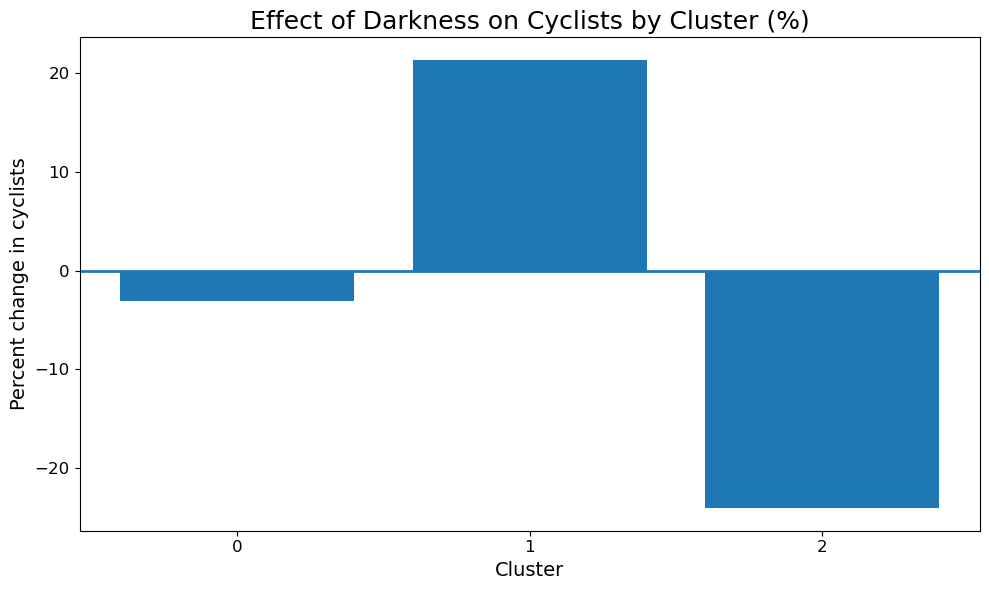

Darkness effect by cluster (%): {0: -3.110537231602195, 1: 21.366873625254932, 2: -24.082719618794357}


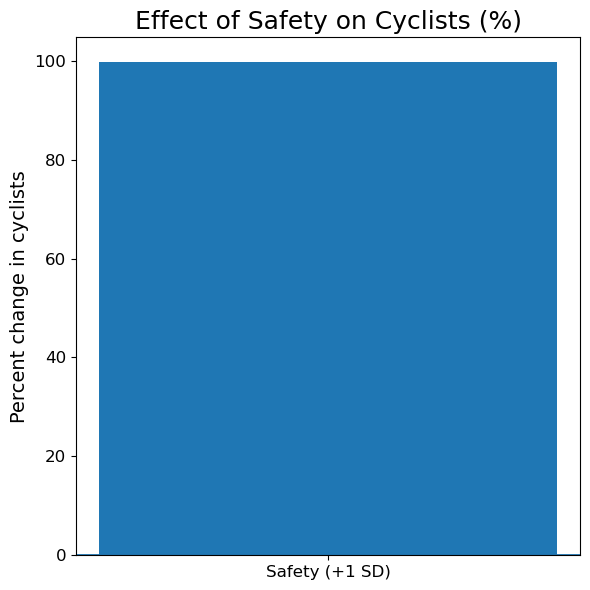

Safety effect (+1 SD) %: 99.74188899606733


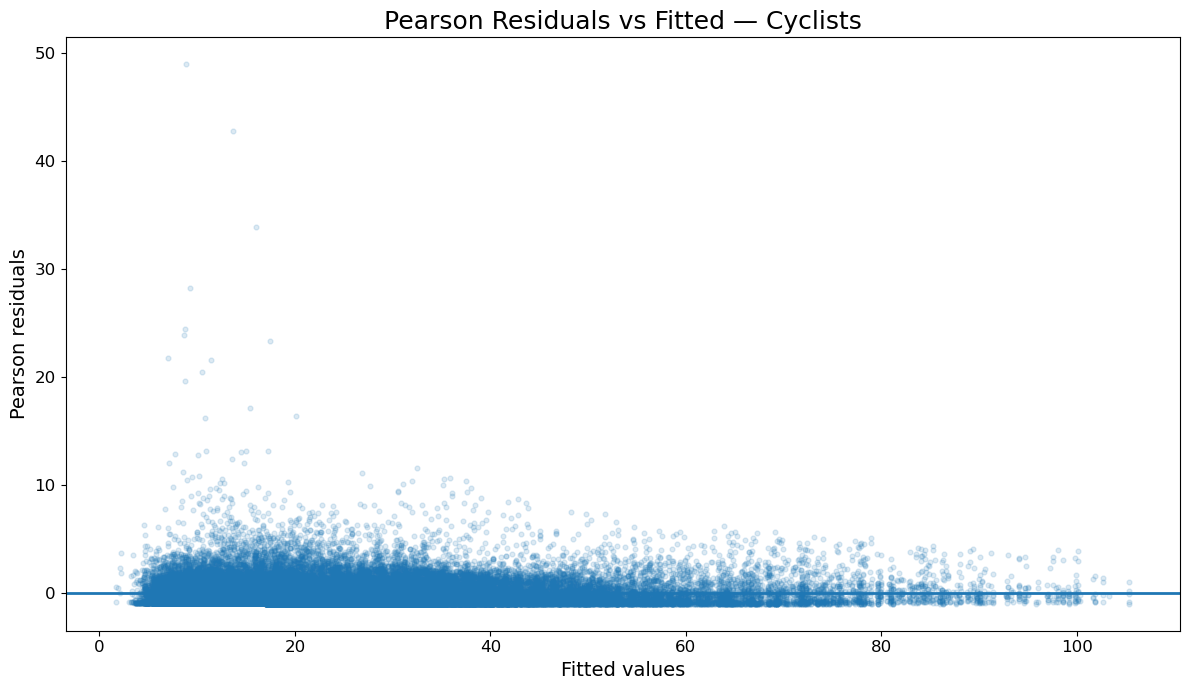

Example sensor for ACF: 2


<Figure size 1200x600 with 0 Axes>

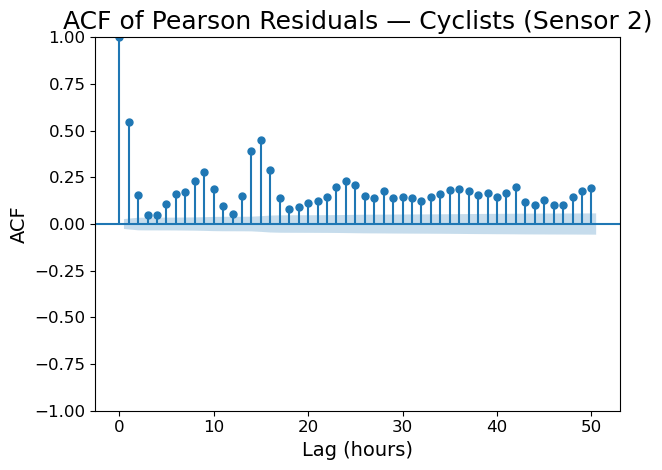

In [37]:

from statsmodels.graphics.tsaplots import plot_acf
# -----------------------------
# CONFIG
# -----------------------------
OUT_FIG_DIR = "../figures"
TAG = "cyc_safety"   # change for other models: "ped_safety", "active_safety"
os.makedirs(OUT_FIG_DIR, exist_ok=True)

# IMPORTANT:
# You must already have:
# - df = dataframe used for fitting (after NA drops etc.)
# - model = fitted statsmodels GLM result

# -----------------------------
# Helper: safe get coef
# -----------------------------
def get_coef(params, name):
    return float(params[name]) if name in params.index else 0.0

params = model.params

# -----------------------------
# 1) Correct cluster-specific darkness effects
# -----------------------------
beta_dark = get_coef(params, "Dark")

beta_dark_c1 = get_coef(params, "Dark:C(cluster_geo)[T.1]")
beta_dark_c2 = get_coef(params, "Dark:C(cluster_geo)[T.2]")

dark_effects = {
    0: beta_dark,
    1: beta_dark + beta_dark_c1,
    2: beta_dark + beta_dark_c2,
}

dark_pct = {k: (np.exp(v) - 1) * 100 for k, v in dark_effects.items()}

# Plot darkness effect
plt.figure(figsize=(10, 6))
plt.bar(list(dark_pct.keys()), list(dark_pct.values()))
plt.axhline(0, linewidth=2)
plt.title("Effect of Darkness on Cyclists by Cluster (%)", fontsize=18)
plt.xlabel("Cluster", fontsize=14)
plt.ylabel("Percent change in cyclists", fontsize=14)
plt.xticks([0, 1, 2], fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_FIG_DIR}/darkness_effect_{TAG}.pdf")
plt.savefig(f"{OUT_FIG_DIR}/darkness_effect_{TAG}.png", dpi=200)
plt.show()

print("Darkness effect by cluster (%):", dark_pct)

# -----------------------------
# 2) Safety effect (per +1 SD if safety_scaled is z-score)
# -----------------------------
beta_safety = get_coef(params, "safety_scaled")
safety_pct_1sd = (np.exp(beta_safety) - 1) * 100

plt.figure(figsize=(6, 6))
plt.bar(["Safety (+1 SD)"], [safety_pct_1sd])
plt.axhline(0, linewidth=2)
plt.title("Effect of Safety on Cyclists (%)", fontsize=18)
plt.ylabel("Percent change in cyclists", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_FIG_DIR}/safety_effect_{TAG}.pdf")
plt.savefig(f"{OUT_FIG_DIR}/safety_effect_{TAG}.png", dpi=200)
plt.show()

print("Safety effect (+1 SD) %:", safety_pct_1sd)

# -----------------------------
# 3) Pearson residuals vs fitted (sampled)
# -----------------------------
fitted = model.fittedvalues
pearson_resid = model.resid_pearson

# sample for plotting clarity
n = len(df)
sample_n = min(60000, n)
idx = np.random.RandomState(42).choice(np.arange(n), size=sample_n, replace=False)

plt.figure(figsize=(12, 7))
plt.scatter(fitted.iloc[idx], pearson_resid.iloc[idx], alpha=0.15, s=12)
plt.axhline(0, linewidth=2)
plt.title("Pearson Residuals vs Fitted — Cyclists", fontsize=18)
plt.xlabel("Fitted values", fontsize=14)
plt.ylabel("Pearson residuals", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_FIG_DIR}/residuals_vs_fitted_{TAG}.pdf")
plt.savefig(f"{OUT_FIG_DIR}/residuals_vs_fitted_{TAG}.png", dpi=200)
plt.show()

# -----------------------------
# 4) ACF of residuals for ONE explicit example sensor
# -----------------------------
# Pick the highest-traffic sensor (more stable ACF than a near-zero sensor)
sensor_totals = df.groupby("sensor_id")["cyc"].sum().sort_values(ascending=False)
example_sensor = int(sensor_totals.index[0])
print("Example sensor for ACF:", example_sensor)

df_ex = df[df["sensor_id"] == example_sensor].copy()
# Must sort by time!
df_ex = df_ex.sort_values("datetime")

# Map residuals to df rows: assume df index aligns with model rows
# If you reset index earlier, do NOT reset it; keep original row order.
resid_ex = pearson_resid.loc[df_ex.index]

plt.figure(figsize=(12, 6))
plot_acf(resid_ex, lags=50, alpha=0.05)
plt.title(f"ACF of Pearson Residuals — Cyclists (Sensor {example_sensor})", fontsize=18)
plt.xlabel("Lag (hours)", fontsize=14)
plt.ylabel("ACF", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_FIG_DIR}/acf_residuals_{TAG}.pdf")
plt.savefig(f"{OUT_FIG_DIR}/acf_residuals_{TAG}.png", dpi=200)
plt.show()